# Image Classification
Vincent Luong

## Introduction

Write a brief summary about image classification and pytorch

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import ToTensor
import torchvision.transforms as tt
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

## Importing the Dataset

We will need to first normalize the image tensors by subtracting the mean and dividing by the standard deviation across each channel.  As a result, the mean of the data across each channel is 0, and the standard deviation is 1 ~ N(0,1). Normallizing the data prevents the values from any one channel from disproportionately affecting the losses a nd gradients while training, simply by having a higher or wider range of values.

In [2]:
train = ImageFolder("../image-classification/data/seg_train", transform = tt.Compose([
    tt.Resize(64),
    tt.RandomCrop(64),
    tt.ToTensor(),
]))
train_dl = DataLoader(train, 64, shuffle=True, num_workers=3, pin_memory=True)

def get_mean_std(dl):
    sum_, squared_sum, batches = 0,0,0
    for data, _ in dl:
        sum_ += torch.mean(data, dim = ([0,2,3]))
        squared_sum += torch.mean(data**2, dim = ([0,2,3]))
        batches += 1
        
    mean = sum_/batches
    std = (squared_sum/batches - mean**2)**0.5
    return mean,std

mean, std = get_mean_std(train_dl)
mean, std

(tensor([0.4302, 0.4575, 0.4539]), tensor([0.2480, 0.2466, 0.2806]))

We will then apply random chosen transformations while loading images from the training set, more specifically, we will pad each image by 4 pixels, and then take a random crop of 64 x 64 pixels, and then flip the image horizontally with a 50% probability.  Since the transformation will be applied randomly and dynamically each time a particular image is loaded, the model sees a slightly different image in each *epoch* of training, allowing for a better generalization.

In [3]:
stats = ((0.4951, 0.4982, 0.4979), (0.2482, 0.2467, 0.2807))
train_transform = tt.Compose([
    tt.Resize(64),
    tt.RandomCrop(64),
    tt.RandomHorizontalFlip(),
    tt.ToTensor(),
    tt.Normalize(*stats,inplace=True)
])

test_transform = tt.Compose([
    tt.Resize(64),
    tt.RandomCrop(64),
    tt.ToTensor(),
    tt.Normalize(*stats,inplace=True)
])

## Creating a Train/Test Split

In [4]:
train = ImageFolder("../image-classification/data/seg_train", transform = train_transform)
test = ImageFolder("../image-classification/data/seg_test",transform = test_transform)

After importing the following images into our jupyter notebook, we will split our dataset into 2 parts.  In our case of **image classification**, we will have a training set `train_dat` for training our model; we will be working with this for model construction.  

Additionally, we also create a testing set `test_dat`, these images will be unseen and be used to test our model accuracy.

We will be using a 80/20 train/test split to train our model

In [5]:
torch.manual_seed(42)

test_size = int(len(train) * 0.2)
train_size = len(train) - test_size

train_dat, test_dat = random_split(train, [train_size, test_size])
len(train_dat), len(test_dat)

(11228, 2806)

## Creating Data Loaders to Retrieve Images in Data

We will use a relatively large batch size of 128 to utilize a larger portion of our GPU RAM.

In [6]:
batch_size = 128

# PyTorch data loaders
train_dl = DataLoader(train_dat, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dl = DataLoader(test_dat, batch_size*2, num_workers=2, pin_memory=True)
test_dl = DataLoader(test, batch_size*2, num_workers=2, pin_memory=True)

Looking at some sample images from the training dataloader, we'll first need to denormalize the pixels values to bring them back into the range (0,1).

In [11]:
def denormalize(images, means, stds):
    means = torch.tensor(means).reshape(1, 3, 1, 1)
    stds = torch.tensor(stds).reshape(1, 3, 1, 1)
    return images * stds + means

def show_batch(dl, classes):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        denorm_images = denormalize(images, *stats)
        ax.imshow(make_grid(denorm_images[:64], nrow=8).permute(1, 2, 0).clamp(0,1))
        print("Labels:", [classes[label] for label in labels[:64]])
        break

Labels: ['seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train', 'seg_train']


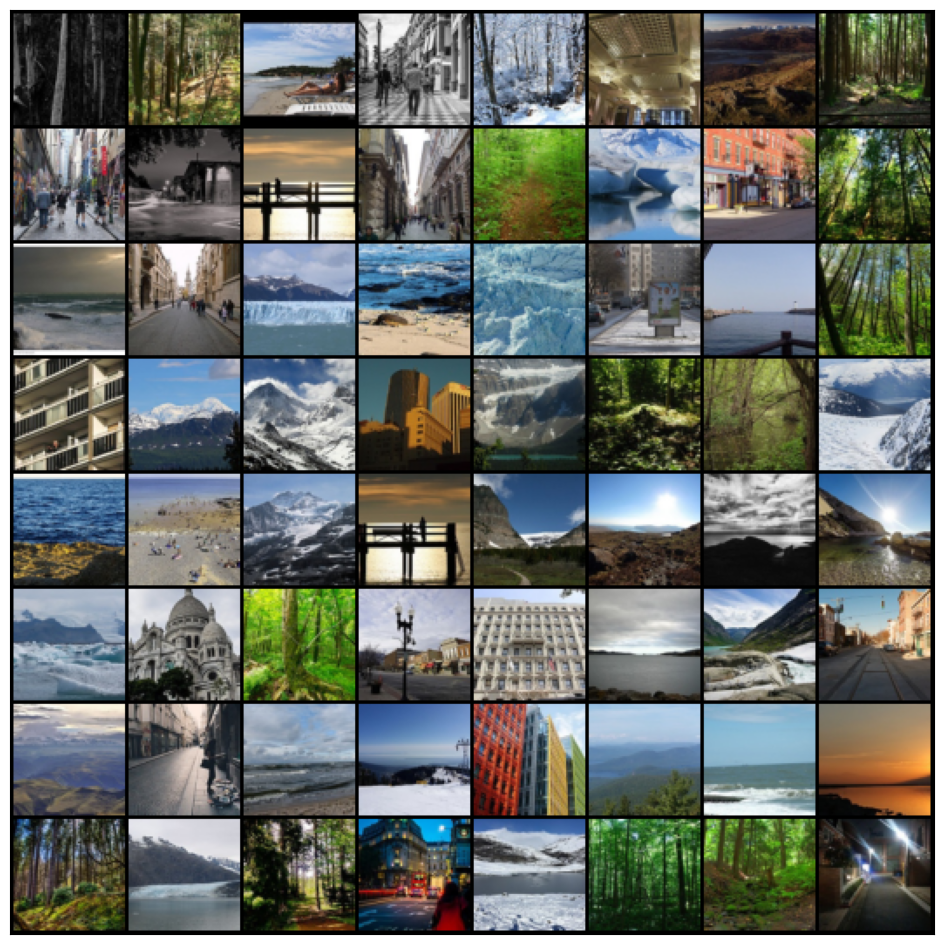

In [12]:
show_batch(train_dl, train.classes)

## Utility Functions and Classes

We will define new functions and classes to move data into our GPU, significantly boosting training speed, thus increasing our model speed.

In [28]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

**Note**: We will define a class `ImageClassificationBase` as the base class, which keep tracks of the losses and every epoch in our training.

In [29]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']))

We will then move the data into the gpu in hopes for better optimization

In [30]:
device = get_default_device()
device

device(type='cpu')

In [31]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)
test_dl = DeviceDataLoader(test_dl, device)